# Posttest 3 — Machine Learning
## Klasifikasi Species Penguin dengan Supervised Learning

**Nama:** Intan Alfara Audia  
**Kelas:** A1'24


## 1. Pendahuluan

Pada posttest ini saya menggunakan pendekatan **Supervised Learning** dengan tugas klasifikasi. Dataset yang digunakan adalah data penguin, dengan `Species` sebagai target yang akan diprediksi.

Untuk variabel input, saya menggunakan empat karakteristik fisik penguin, yaitu `Culmen Length`, `Culmen Depth`, `Flipper Length`, dan `Body Mass`.


## 2. Import Library

Pada tahap ini saya mengimpor beberapa library yang digunakan untuk mengolah data, membuat model machine learning, melakukan evaluasi, dan menampilkan hasil dalam bentuk grafik.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")

## 3. Membaca Dataset

Dataset yang digunakan adalah `penguins_lter.csv`. Pada tahap ini dataset dibaca terlebih dahulu untuk mengetahui jumlah data dan atribut yang tersedia.

Saya juga menampilkan beberapa data awal agar dapat melihat bentuk data yang akan digunakan sebelum masuk ke proses pemodelan.


In [ ]:
df = pd.read_csv("penguins_lter.csv")

print("Jumlah record :", df.shape[0])
print("Jumlah attribute :", df.shape[1])
display(df.head())

Jumlah record : 344
Jumlah attribute : 17


,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN


## 4. Pemeriksaan Target

Sebelum membuat model, saya melihat jumlah data pada masing-masing `Species`. Hal ini dilakukan untuk mengetahui penyebaran data pada setiap kelas yang akan diprediksi.

Jumlah masing-masing Species:


,count
Species,
Adelie Penguin (Pygoscelis adeliae),152
Gentoo penguin (Pygoscelis papua),124
Chinstrap penguin (Pygoscelis antarctica),68


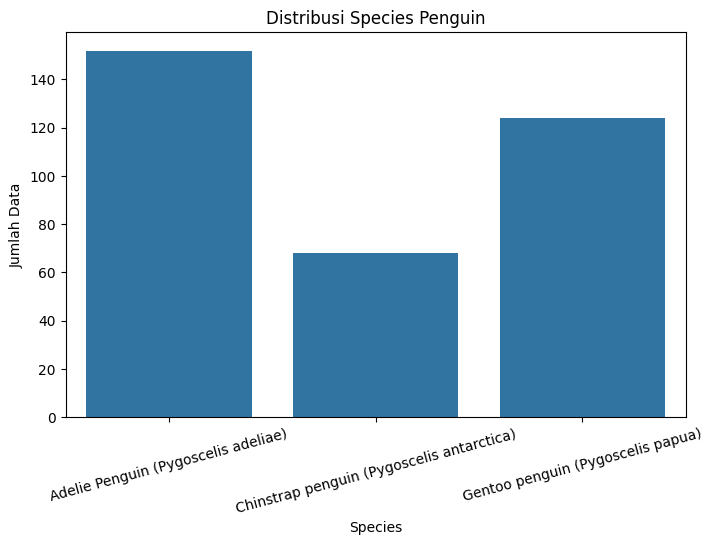

In [ ]:
print("Jumlah masing-masing Species:")
display(df["Species"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Species")
plt.title("Distribusi Species Penguin")
plt.xlabel("Species")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=15)
plt.show()

## 5. Menentukan Variabel X dan Y

Pada proses ini `Species` digunakan sebagai **Y atau target** yang akan diprediksi.

Sedangkan variabel **X** terdiri dari empat karakteristik fisik, yaitu:
- `Culmen Length`
- `Culmen Depth`
- `Flipper Length`
- `Body Mass`

Keempat variabel tersebut digunakan sebagai input untuk membantu model membedakan species penguin.

In [ ]:
feature_columns = [
    "Culmen Length (mm)",
    "Culmen Depth (mm)",
    "Flipper Length (mm)",
    "Body Mass (g)"
]

target_column = "Species"

X = df[feature_columns].copy()
y = df[target_column].copy()

# Menangani missing value pada fitur dengan median
X = X.fillna(X.median())

print("Variabel X:")
display(X.head())

print("\nTarget Y:")
display(y.head())

Variabel X:


,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,39.10,18.7,181.0,3750.0
1,39.50,17.4,186.0,3800.0
2,40.30,18.0,195.0,3250.0
3,44.45,17.3,197.0,4050.0
4,36.70,19.3,193.0,3450.0



Target Y:


,Species
0,Adelie Penguin (Pygoscelis adeliae)
1,Adelie Penguin (Pygoscelis adeliae)
2,Adelie Penguin (Pygoscelis adeliae)
3,Adelie Penguin (Pygoscelis adeliae)
4,Adelie Penguin (Pygoscelis adeliae)


## 6. Data Splitting

Data kemudian dibagi menjadi data training dan data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk melihat kemampuan model dalam melakukan prediksi pada data yang belum digunakan saat proses training.

Pada penelitian ini saya menggunakan pembagian **80% data training dan 20% data testing**.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Jumlah data training :", len(X_train))
print("Jumlah data testing  :", len(X_test))

Jumlah data training : 275
Jumlah data testing  : 69


## 7. Training Model SVM

Pada tahap ini saya menggunakan Support Vector Machine (SVM) sebagai salah satu model klasifikasi.

Data distandarisasi terlebih dahulu agar skala setiap variabel lebih seimbang. Setelah itu model dilatih menggunakan data training untuk mempelajari pola dari data penguin.

In [ ]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", random_state=42))
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("Training SVM selesai.")

Training SVM selesai.


## 8. Training Model Random Forest

Selain SVM, saya menggunakan Random Forest sebagai model pembanding.
Model ini digunakan untuk melihat perbedaan hasil klasifikasi ketika dataset yang sama diproses menggunakan algoritma yang berbeda.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Training Random Forest selesai.")

Training Random Forest selesai.


## 9. Evaluasi Model

Setelah model selesai dilatih, hasil prediksi dibandingkan dengan data sebenarnya.

Evaluasi dilakukan menggunakan Accuracy, Precision, Recall, dan F1-Score. Dengan menggunakan beberapa metrik, performa model dapat dilihat dari beberapa sisi dan tidak hanya berdasarkan satu nilai saja.

In [ ]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

results = pd.DataFrame([
    evaluate_model("SVM", y_test, y_pred_svm),
    evaluate_model("Random Forest", y_test, y_pred_rf)
])

# Menampilkan hasil dengan angka yang lebih rapi
display(
    results.style
    .format({
        "Accuracy": "{:.2%}",
        "Precision": "{:.2%}",
        "Recall": "{:.2%}",
        "F1-Score": "{:.2%}"
    })
    .set_caption("Hasil Evaluasi Model")
)

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,98.55%,98.65%,98.55%,98.56%
1,Random Forest,98.55%,98.65%,98.55%,98.56%


## 10. Classification Report

Classification report digunakan untuk melihat nilai precision, recall, dan F1-Score pada masing-masing species.
Dari hasil ini dapat dilihat apakah model memberikan hasil yang baik pada setiap kelas atau masih terdapat species yang lebih sering mengalami kesalahan prediksi.

In [ ]:
print("Classification Report - SVM")
print(classification_report(y_test, y_pred_svm, zero_division=0))

print("\nClassification Report - Random Forest")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Classification Report - SVM
                                           precision    recall  f1-score   support

      Adelie Penguin (Pygoscelis adeliae)       1.00      0.97      0.98        30
Chinstrap penguin (Pygoscelis antarctica)       0.93      1.00      0.97        14
        Gentoo penguin (Pygoscelis papua)       1.00      1.00      1.00        25

                                 accuracy                           0.99        69
                                macro avg       0.98      0.99      0.98        69
                             weighted avg       0.99      0.99      0.99        69


Classification Report - Random Forest
                                           precision    recall  f1-score   support

      Adelie Penguin (Pygoscelis adeliae)       1.00      0.97      0.98        30
Chinstrap penguin (Pygoscelis antarctica)       0.93      1.00      0.97        14
        Gentoo penguin (Pygoscelis papua)       1.00      1.00      1.00        25

               

## 11. Confusion Matrix SVM

Confusion matrix digunakan untuk melihat perbandingan antara species sebenarnya dengan species hasil prediksi.

Nilai pada bagian diagonal menunjukkan jumlah data yang berhasil diprediksi dengan benar, sedangkan nilai di luar diagonal menunjukkan data yang mengalami kesalahan klasifikasi.

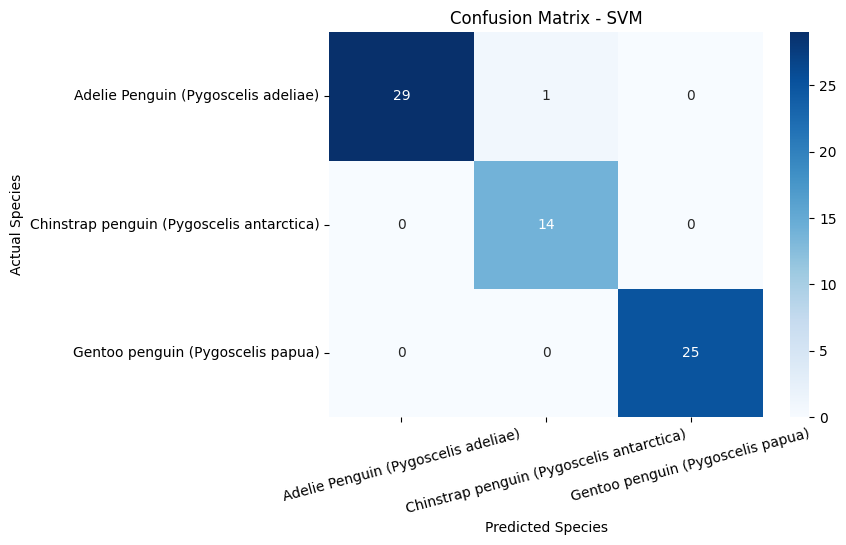

In [ ]:
labels = sorted(y.unique())

cm_svm = confusion_matrix(y_test, y_pred_svm, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.show()

## 12. Confusion Matrix Random Forest

Confusion matrix Random Forest digunakan untuk melihat hasil prediksi setiap species dan mengetahui bagian data yang berhasil maupun yang masih salah diprediksi oleh model.

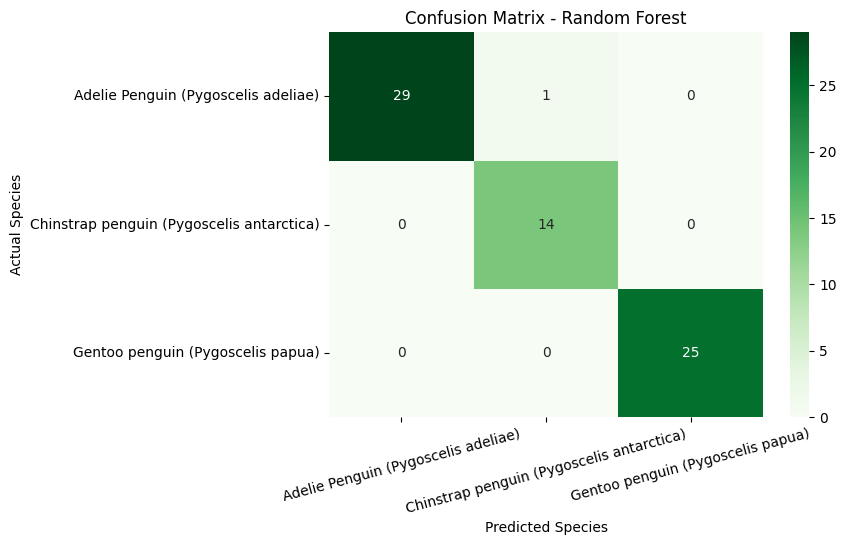

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.xticks(rotation=15)
plt.yticks(rotation=0)
plt.show()

## 13. Grafik Actual vs Predicted

Grafik ini digunakan untuk melihat perbandingan antara species sebenarnya dengan hasil prediksi SVM pada data testing.

Dari grafik ini dapat dilihat apakah hasil prediksi model sudah sesuai dengan data sebenarnya atau masih terdapat beberapa data yang berbeda.

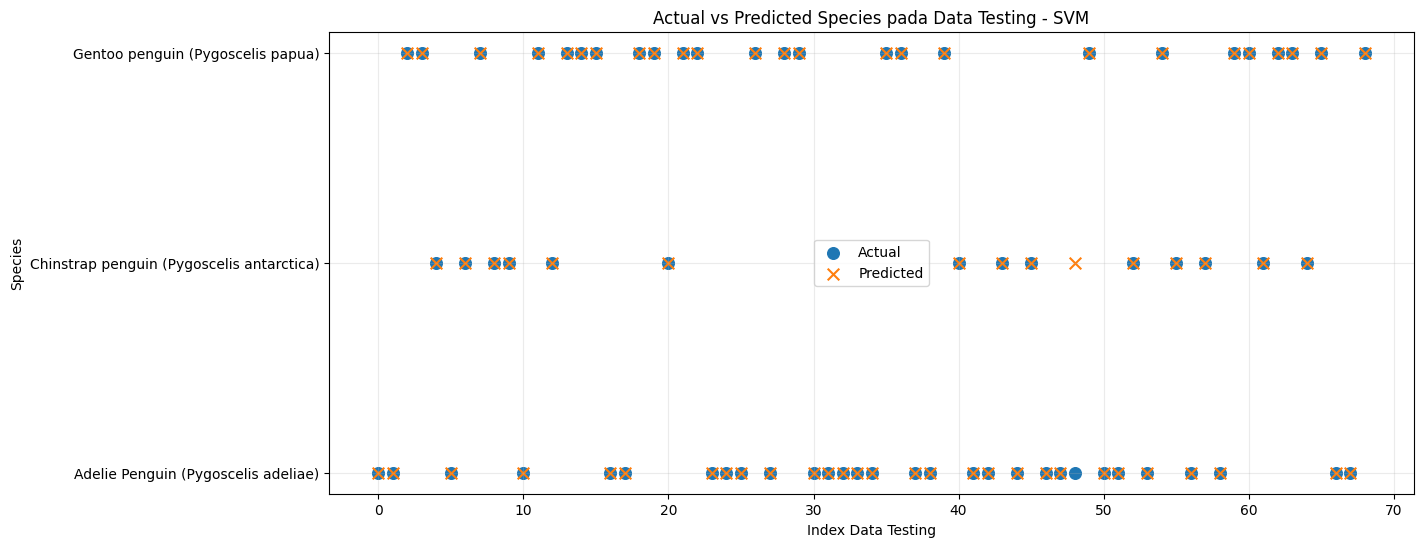

Jumlah prediksi benar : 68 data
Jumlah prediksi salah : 1 data


In [ ]:
plot_df = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Predicted": pd.Series(y_pred_svm)
})

actual_codes = pd.Categorical(plot_df["Actual"], categories=labels).codes
pred_codes = pd.Categorical(plot_df["Predicted"], categories=labels).codes

plt.figure(figsize=(14, 6))
plt.scatter(range(len(plot_df)), actual_codes, label="Actual", marker="o", s=70)
plt.scatter(range(len(plot_df)), pred_codes, label="Predicted", marker="x", s=70)

plt.yticks(range(len(labels)), labels)
plt.title("Actual vs Predicted Species pada Data Testing - SVM")
plt.xlabel("Index Data Testing")
plt.ylabel("Species")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plot_df["Benar"] = plot_df["Actual"] == plot_df["Predicted"]
print(f"Jumlah prediksi benar : {plot_df["Benar"].sum()} data")
print(f"Jumlah prediksi salah : {(~plot_df["Benar"]).sum()} data")

## 14. Perbandingan Performa Model

Setelah mendapatkan hasil dari kedua model, saya membandingkan nilai Accuracy, Precision, Recall, dan F1-Score.

Perbandingan ini dilakukan untuk melihat bagaimana performa SVM dan Random Forest ketika digunakan pada dataset yang sama.

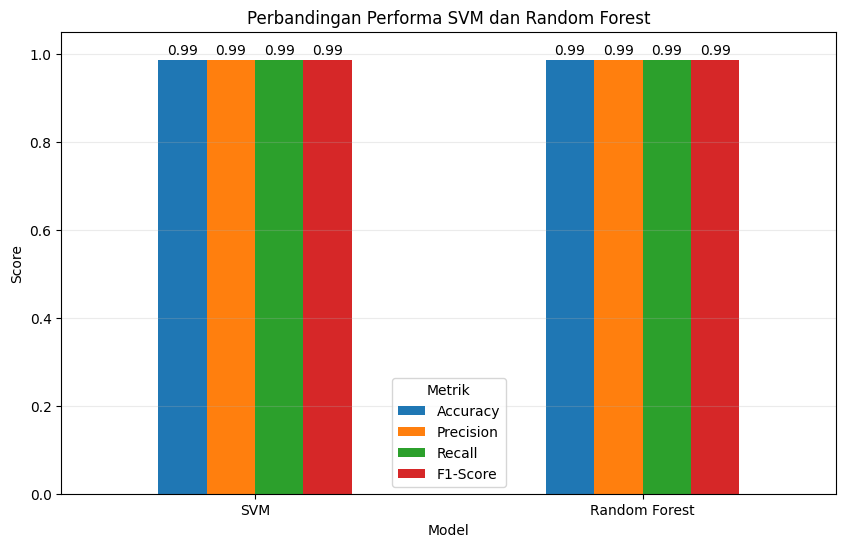

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
plot_data = results.set_index("Model")[metrics]

ax = plot_data.plot(kind="bar", figsize=(10, 6))
plt.title("Perbandingan Performa SVM dan Random Forest")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metrik")
plt.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=2)

plt.show()

## 15. Analisis Hasil

Berdasarkan hasil pengujian pada data testing, SVM memperoleh accuracy sebesar **...%**, sedangkan Random Forest memperoleh accuracy sebesar **...%**.

Selain accuracy, precision, recall, dan F1-Score juga digunakan untuk melihat hasil klasifikasi secara lebih lengkap.

Dari confusion matrix dapat dilihat bahwa sebagian besar data berhasil diklasifikasikan sesuai dengan species sebenarnya. Namun, masih terdapat beberapa data yang mengalami kesalahan prediksi. Hal ini menunjukkan bahwa terdapat beberapa data antar-species yang memiliki karakteristik fisik yang cukup mirip.

## 16. Kesimpulan

Pada posttest ini saya telah menerapkan **Supervised Learning** untuk melakukan klasifikasi species penguin.

Empat variabel fisik digunakan sebagai variabel input, yaitu `Culmen Length`, `Culmen Depth`, `Flipper Length`, dan `Body Mass`, sedangkan `Species` digunakan sebagai target.

Model yang digunakan adalah **SVM dan Random Forest**. Hasil kedua model dievaluasi menggunakan Accuracy, Precision, Recall, dan F1-Score serta divisualisasikan menggunakan confusion matrix dan grafik actual vs predicted.

Berdasarkan hasil pengujian pada data testing, kedua model dapat digunakan untuk melakukan klasifikasi species penguin. Hasil evaluasi yang diperoleh dapat digunakan untuk melihat kemampuan masing-masing model dalam melakukan prediksi.